In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from utils import *
from Sampler import *
from network import LPN1
from scipy.signal import fftconvolve

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
np.random.seed(1)
torch.manual_seed(1)

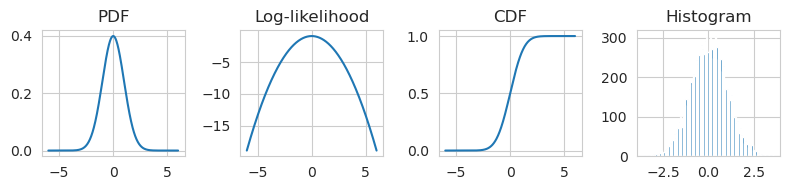

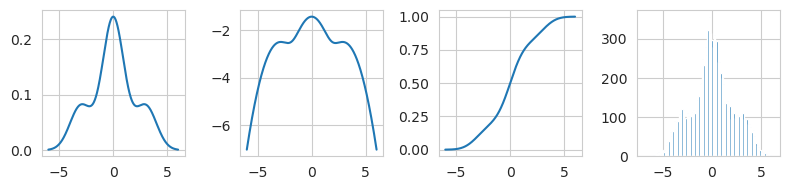

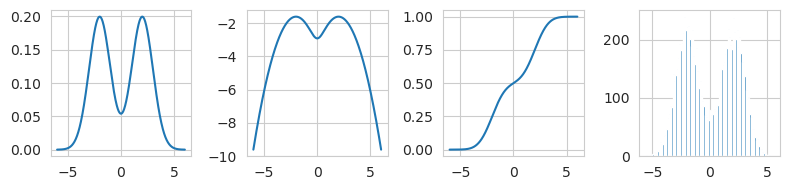

In [2]:
weights1 = torch.tensor([1])
means1   = torch.tensor([0])
stds1    = torch.tensor([1])
weights2 = torch.tensor([.2,.6,.2])
means2   = torch.tensor([-3,0,3])
stds2    = torch.tensor([1,1,1])
weights3 = torch.tensor([.5,.5])
means3   = torch.tensor([-2,2])
stds3    = torch.tensor([1,1])

sampler1 = Sampler(weights1, means1, stds1, "Gaussian")
sampler2 = Sampler(weights2, means2, stds2, "Gaussian")
sampler3 = Sampler(weights3, means3, stds3, "Gaussian")

dist1 = sampler1.dist
dist2 = sampler2.dist
dist3 = sampler3.dist

x = torch.linspace(-6, 6, 500)

plt.rcParams["figure.figsize"] = (8, 2)
plt.subplot(1, 4, 1)
plt.plot(x, dist1.log_prob(x).exp())
plt.title("PDF")
plt.subplot(1, 4, 2)
plt.plot(x, dist1.log_prob(x))
plt.title("Log-likelihood")
plt.subplot(1, 4, 3)
plt.plot(x, dist1.cdf(x))
plt.title("CDF")
plt.subplot(1, 4, 4)
plt.hist(sampler1(10_000).cpu(), bins=100)
plt.title("Histogram")
plt.tight_layout()
plt.show()

plt.rcParams["figure.figsize"] = (8, 2)
plt.subplot(1, 4, 1)
plt.plot(x, dist2.log_prob(x).exp())
plt.subplot(1, 4, 2)
plt.plot(x, dist2.log_prob(x))
plt.subplot(1, 4, 3)
plt.plot(x, dist2.cdf(x))
plt.subplot(1, 4, 4)
plt.hist(sampler2(10_000).cpu(), bins=100)
plt.tight_layout()
plt.show()

plt.rcParams["figure.figsize"] = (8, 2)
plt.subplot(1, 4, 1)
plt.plot(x, dist3.log_prob(x).exp())
plt.subplot(1, 4, 2)
plt.plot(x, dist3.log_prob(x))
plt.subplot(1, 4, 3)
plt.plot(x, dist3.cdf(x))
plt.subplot(1, 4, 4)
plt.hist(sampler3(10_000).cpu(), bins=100)
plt.tight_layout()
plt.show()

In [3]:
IN_DIM = 1
HIDDEN = 50
LAYERS = 4

model1 = LPN1(in_dim=IN_DIM, hidden=HIDDEN, layers=LAYERS).to(device)
model2 = LPN1(in_dim=IN_DIM, hidden=HIDDEN, layers=LAYERS).to(device)
model3 = LPN1(in_dim=IN_DIM, hidden=HIDDEN, layers=LAYERS).to(device)

In [4]:
def add_noise(x, sigma=0.1):
    noise = torch.randn_like(x) * sigma
    return x + noise

def single_iteration(i, bsize, sigma_noise, optimizer, model=None, sampler=None):
    if sampler is None:
        raise ValueError("No sampler.")
    if model is None:
        raise ValueError("No model.")


    target = sampler(bsize).unsqueeze(1)
    input = add_noise(target, sigma_noise)
    input, target = input.to(device), target.to(device)
    out = model(input)

    loss = (out - target).pow(2).sum() / bsize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss

In [5]:
BSIZE = 2000
SIGMA_NOISE = 1
optimizer1 = torch.optim.Adam(model1.parameters(), lr=1e-3)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=1e-3)
optimizer3 = torch.optim.Adam(model3.parameters(), lr=1e-3)

In [6]:
for i in range(500):
        single_iteration(i, BSIZE, SIGMA_NOISE, optimizer1, model=model1, sampler=sampler1)
for g in optimizer1.param_groups:
        g["lr"] = 1e-4
for i in range(500):
        single_iteration(i, BSIZE, SIGMA_NOISE, optimizer1, model=model1, sampler=sampler1)

In [7]:
for i in range(500):
        single_iteration(i, BSIZE, SIGMA_NOISE, optimizer2, model=model2, sampler=sampler2)
for g in optimizer2.param_groups:
        g["lr"] = 1e-4
for i in range(500):
        single_iteration(i, BSIZE, SIGMA_NOISE, optimizer2, model=model2, sampler=sampler2)

In [8]:
for i in range(500):
        single_iteration(i, BSIZE, SIGMA_NOISE, optimizer3, model=model3, sampler=sampler3)
for g in optimizer3.param_groups:
        g["lr"] = 1e-4
for i in range(500):
        single_iteration(i, BSIZE, SIGMA_NOISE, optimizer3, model=model3, sampler=sampler3)

In [9]:
x = np.linspace(-5,5, 100)
p1_estimate = prior(x,model1)
p2_estimate = prior(x,model2)
p3_estimate = prior(x,model3)
moreau1 = calculate_moreau_envelope_learned(x, model1, prior, prox)
moreau2 = calculate_moreau_envelope_learned(x, model2, prior, prox)
moreau3 = calculate_moreau_envelope_learned(x, model3, prior, prox)

mse 8.501701354980469
mse 6.248709201812744
mse 4.592116832733154
mse 3.3017120361328125
mse 2.298008441925049
mse 1.7905977964401245
mse 1.5917184352874756
mse 1.5035674571990967
mse 1.4580217599868774
mse 1.43179190158844
final mse 1.4156649112701416
mse 8.501697540283203
mse 5.522275447845459
mse 2.71669340133667
mse 1.1388444900512695
mse 0.6014775633811951
mse 0.36733368039131165
mse 0.24027098715305328
mse 0.16256912052631378
mse 0.11165803670883179
mse 0.07732468098402023
final mse 0.054352130740880966
mse 8.501687049865723
mse 3.978548526763916
mse 2.673898935317993
mse 2.051363706588745
mse 1.6395655870437622
mse 1.317069172859192
mse 1.0415304899215698
mse 0.8007460832595825
mse 0.5983014702796936
mse 0.4413522183895111
final mse 0.3304273188114166
mse 2.064812660217285
mse 1.0792747735977173
mse 0.5469154715538025
mse 0.2583939731121063
mse 0.10540195554494858
mse 0.039156436920166016
mse 0.015735561028122902
mse 0.007292396854609251
mse 0.0038200770504772663
mse 0.002190183

In [10]:
x=torch.linspace(-5,5,100)
f_X1 = -sampler1.dist.log_prob(x).numpy()
f_X2 = -sampler2.dist.log_prob(x).numpy()
f_X3 = -sampler3.dist.log_prob(x).numpy()

In [11]:

title1 = r"$\mathcal{N}(0,1)$"
title2 = r"$\frac{1}{5}\mathcal{N}(-3,1)+\frac{3}{5}\mathcal{N}(0,1)+\frac{1}{5}\mathcal{N}(3,1)$"
title3 = r"$\frac{1}{2}\mathcal{N}(-2,1)+\frac{1}{2}\mathcal{N}(2,1)$"

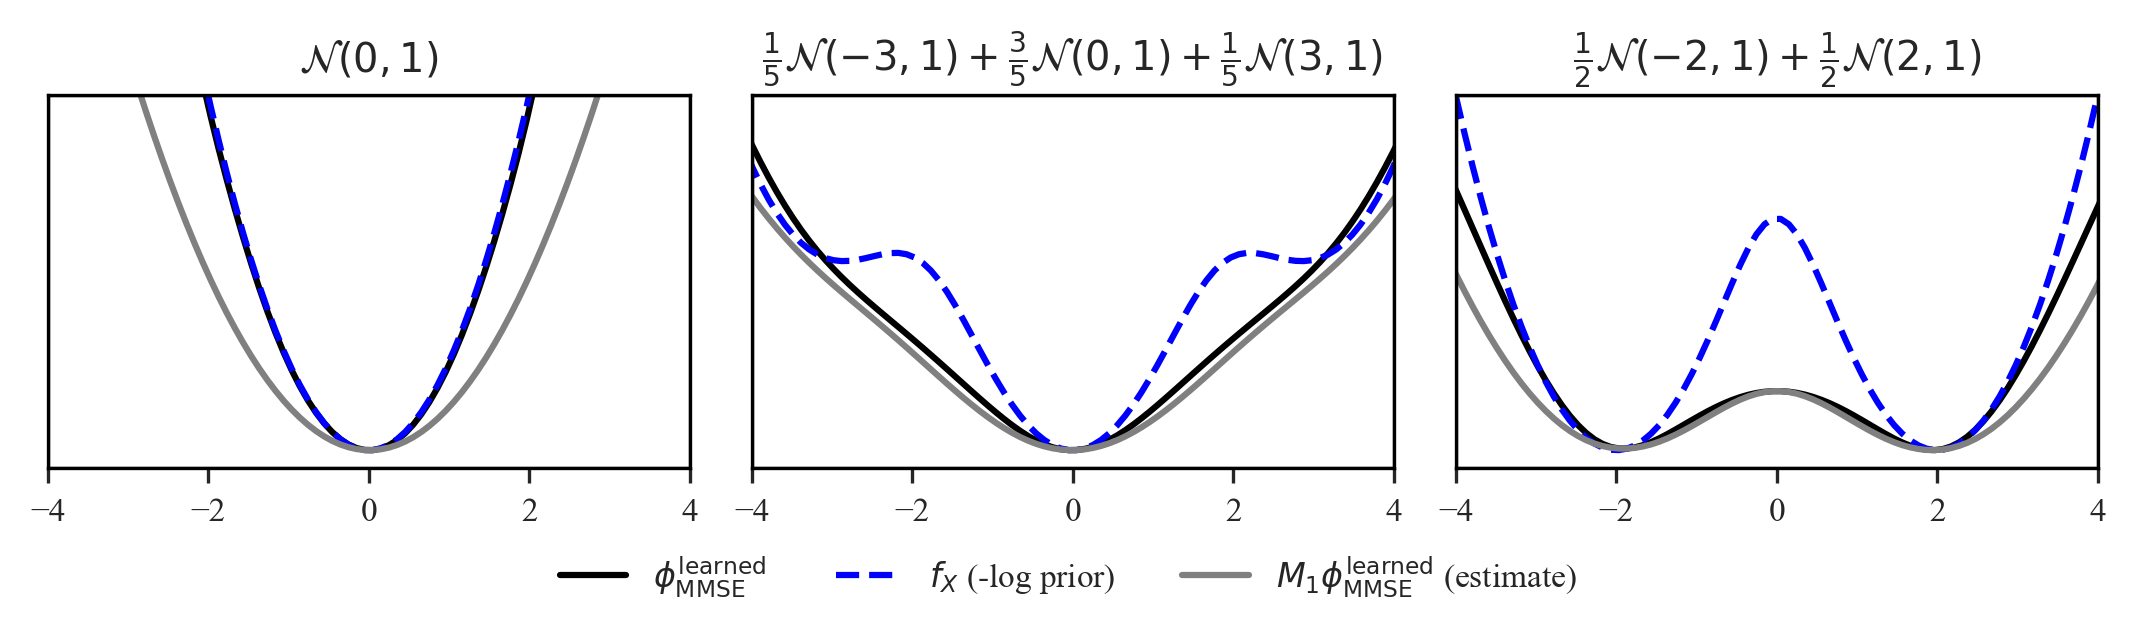

In [12]:
from matplotlib.patches import Rectangle
import matplotlib
matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 8,
    'axes.grid': False,
    'figure.dpi': 300,
    'text.usetex': False,
})

fig, axes = plt.subplots(1, 3, figsize=(7.16, 2), sharex=True, sharey=True)
x = np.linspace(-5,5, 100)
datasets = [
    (f_X1, moreau1, p1_estimate, x, title1),
    (f_X2, moreau2, p2_estimate, x, title2),
    (f_X3, moreau3, p3_estimate, x, title3)
]

for ax, (f_X, f_Z, phi, x, title) in zip(axes.flat, datasets):
    ax.set_facecolor("white")

    # Plots

    ax.plot(x, phi - phi.min(), label="$\\phi^{\mathrm{learned}}_{\mathrm{MMSE}}$ ", color="k", linestyle="-")
    ax.plot(x, f_X - f_X.min(), label="$f_X$ (-log prior)", color="blue", linestyle="--")
    ax.plot(x, f_Z - f_Z.min(), label="$M_1\\phi^{\mathrm{learned}}_{\mathrm{MMSE}}$ (estimate)", color="gray", linestyle="-")

    # Titles/limits
    ax.set_title(title)
    ax.set_xlim([-4, 4])
    ax.set_ylim([-0.1, 2])

    # Bottom ticks only
    ax.tick_params(axis="x", bottom=True, labelbottom=True)
    ax.tick_params(axis="y", left=False, labelleft=False)

    # --- Force spines on and visible ---
    ax.set_frame_on(True)
    for side, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(0.8)

    # --- Fallback border (always draws) ---
    ax.add_patch(Rectangle(
        (0, 0), 1, 1,
        transform=ax.transAxes,
        fill=False,
        edgecolor="black",
        linewidth=0.8,
        zorder=10  # on top
    ))

# White figure background
fig.patch.set_facecolor("white")

# One legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08),   # push legend just below the axes area
    borderaxespad=0.0
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("gaussianmixture_estimate.pdf", format="pdf",
    bbox_inches='tight')
plt.show()

In [13]:
def mog(weights, means, stds, x):
    w = np.atleast_1d(weights).astype(float)
    m = np.atleast_1d(means).astype(float)
    s = np.atleast_1d(stds).astype(float)
    assert w.size == m.size == s.size, "weights, means, stds must have same length"
    # (optional) normalize weights if not exactly 1
    w = w / w.sum()
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x, dtype=float)
    for wi, mi, si in zip(w, m, s):
        out += wi * (1.0 / (np.sqrt(2*np.pi)*si)) * np.exp(-0.5*((x - mi)/si)**2)
    return out


def mlaplace(weights, means, bs, x):
    w = np.atleast_1d(weights).astype(float)
    m = np.atleast_1d(means).astype(float)
    b = np.atleast_1d(bs).astype(float)
    assert w.size == m.size == b.size, "weights, means, bs must have same length"
    w = w / w.sum()
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x, dtype=float)
    for wi, mi, bi in zip(w, m, b):
        out += wi * (1.0/(2.0*bi)) * np.exp(-np.abs(x - mi)/bi)
    return out


x = np.linspace(-8, 8, 1000)
xi = np.linspace(-8, 8, 1000)
weights1 = np.array([1.0])
means1   = np.array([0.0])
stds1    = np.array([1.0])

p_noise = mog(weights1, means1, stds1, x)
p_X1 = mog(weights1, means1, stds1, x)
p_Y1 = fftconvolve(p_X1, p_noise,mode="same")
f_Y1 = -np.log(np.clip(p_Y1, 1e-300, None))
MMSE_estimator1 = x - np.gradient(f_Y1, x)
phi_MMSE1 = f_Y1-.5*(MMSE_estimator1-x)**2
p_noise1 = mog(weights1, means1, stds1, MMSE_estimator1)
p_X1 = mog(weights1, means1, stds1, MMSE_estimator1)
p_Y1 = fftconvolve(p_X1, p_noise1,mode="same")
f_X1 = -np.log(np.clip(p_X1, 1e-300, None))
f_Z1 = -np.log(np.clip(p_Y1, 1e-300, None))

weights2 = np.array([0.2, 0.6, 0.2])
means2   = np.array([-3.0, 0.0, 3.0])
stds2      = np.array([1.0, 1.0, 1.0])
p_X2 = mog(weights2, means2, stds2, x)
p_Y2 = fftconvolve(p_X2, p_noise,mode="same")
f_Y2 = -np.log(np.clip(p_Y2, 1e-300, None))
MMSE_estimator2 = x - np.gradient(f_Y2,x)
phi_MMSE2 = f_Y2-.5*(MMSE_estimator2-x)**2
p_X2 = mog(weights2, means2, stds2, MMSE_estimator2)
p_noise2 = mog(weights1, means1, stds1, MMSE_estimator2)
p_Y2 = fftconvolve(p_X2, p_noise2,mode="same")
f_X2 = -np.log(np.clip(p_X2, 1e-300, None))
f_Z2 = -np.log(np.clip(p_Y2, 1e-300, None))

p_X3 = mog(weights3, means3, stds3, x)
p_Y3 = fftconvolve(p_X3, p_noise, mode="same")
f_Y3 = -np.log(np.clip(p_Y3, 1e-300, None))
MMSE_estimator3 = x - np.gradient(f_Y3,x)
phi_MMSE3 = f_Y3-.5*(MMSE_estimator3-x)**2
p_X3 = mog(weights3, means3, stds3, MMSE_estimator3)
p_noise3 = mog(weights1, means1, stds1, MMSE_estimator3)
p_Y3 = fftconvolve(p_X3, p_noise3,mode="same")
f_X3 = -np.log(np.clip(p_X3, 1e-300, None))
f_Z3 = -np.log(np.clip(p_Y3, 1e-300, None))


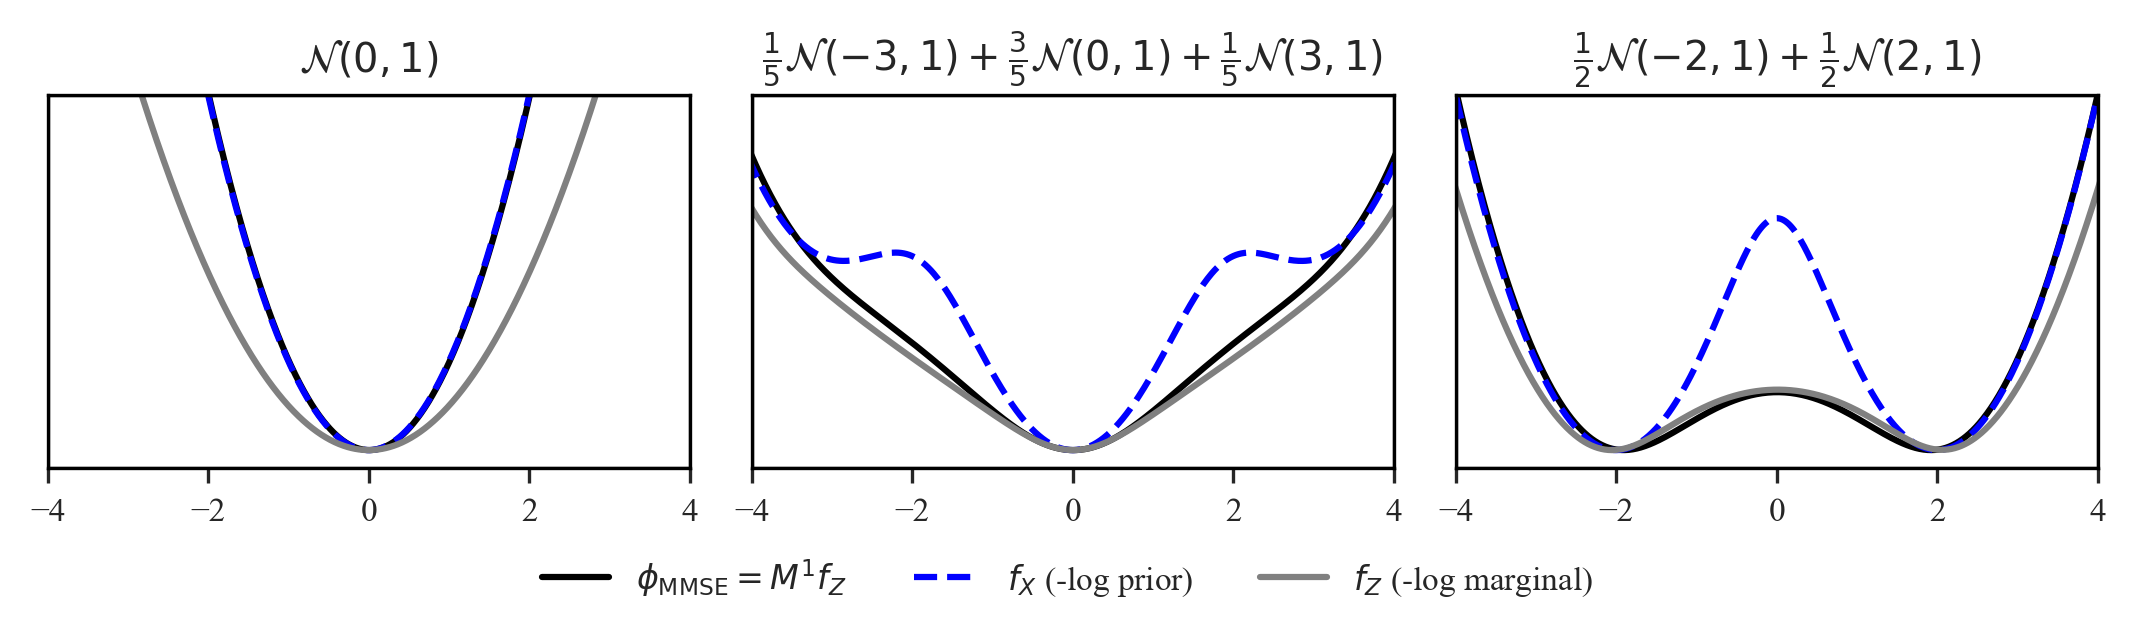

In [14]:
from matplotlib.patches import Rectangle
import matplotlib
matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 8,
    'axes.grid': False,
    'figure.dpi': 300,
    'text.usetex': False,
})

fig, axes = plt.subplots(1, 3, figsize=(7.16, 2), sharex=True, sharey=True)
datasets = [
    (f_X1, f_Z1, phi_MMSE1, MMSE_estimator1, title1),
    (f_X2, f_Z2, phi_MMSE2, MMSE_estimator2, title2),
    (f_X3, f_Z3, phi_MMSE3, MMSE_estimator3, title3)
]

for ax, (f_X, f_Z, phi, x, title) in zip(axes.flat, datasets):
    ax.set_facecolor("white")

    # Plots

    ax.plot(x, phi - phi.min(), label="$\\phi_{\mathrm{MMSE}} = M^1f_Z$ ", color="k", linestyle="-")
    ax.plot(x, f_X - f_X.min(), label="$f_X$ (-log prior)", color="blue", linestyle="--")
    ax.plot(x, f_Z - f_Z.min(), label=r"$f_Z $ (-log marginal)", color="gray", linestyle="-")

    # Titles/limits
    ax.set_title(title)
    ax.set_xlim([-4, 4])
    ax.set_ylim([-0.1, 2])

    # Bottom ticks only
    ax.tick_params(axis="x", bottom=True, labelbottom=True)
    ax.tick_params(axis="y", left=False, labelleft=False)

    # --- Force spines on and visible ---
    ax.set_frame_on(True)
    for side, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(0.8)

    # --- Fallback border (always draws) ---
    ax.add_patch(Rectangle(
        (0, 0), 1, 1,
        transform=ax.transAxes,
        fill=False,
        edgecolor="black",
        linewidth=0.8,
        zorder=10  # on top
    ))

# White figure background
fig.patch.set_facecolor("white")

# One legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08),   # push legend just below the axes area
    borderaxespad=0.0
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("gaussianmixture_calculated.pdf", format="pdf",
    bbox_inches='tight')
plt.show()